In [2]:
import pandas as pd
import gzip
from pathlib import Path

# 1. Define paths
data_dir = Path("../../../data/indels/filtered_vcf")
master_list_path = data_dir / "master.csv"

# 2. Load metadata
df_meta = pd.read_csv(master_list_path)

# Ensure LEGACY and UKCTOCS are grouped as 'PBMCs' (if they aren't already in the CSV)
# This looks for sample IDs starting with either name and forces the sample_type
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

# Helper function to parse VCF and extract INFO fields
def parse_vcf_variants(vcf_file):
    variants = []
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 8:
                continue
            
            ref = parts[3]
            alt = parts[4].split(',')[0]
            
            # Skip SNVs and MNVs
            if len(ref) == len(alt):
                continue
                
            info_field = parts[7]
            info_dict = {}
            for item in info_field.split(';'):
                if '=' in item:
                    k, v = item.split('=', 1)
                    info_dict[k] = v

            n_alt = float(info_dict.get('N_ALT', 0))
            n_total = float(info_dict.get('N_TOTAL', 0))
            
            if n_total > 0:
                variants.append({
                    'CHROM': parts[0],
                    'POS': int(parts[1]),
                    'REF': ref,
                    'ALT': alt,
                    'VAF': n_alt / n_total,
                    'TYPE': 'INS' if len(alt) > len(ref) else 'DEL',
                    'LEN': abs(len(alt) - len(ref)),
                    # --- NEW DIAGNOSTIC FIELDS ---
                    'Homopolymer_Length': int(float(info_dict.get('HOMOPOLYMER_LEN', 0))),
                    'Read_Position': float(info_dict.get('RP_MED_SSCS', 0.5)),
                    'Strand_Bias': float(info_dict.get('STRAND_BIAS_SSCS', 0.5))
                })
                
    return pd.DataFrame(variants)

# 3. Process all samples
all_variants_list = []
burden_summary_list = []

print("Loading VCFs and calculating burden...")

for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    
    # Dynamically find the VCF file in the ../Data directory based on sample_id
    search_pattern = f"{sample_id}.indel_candidates_annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        print(f"  [Warning] VCF not found for {sample_id}. Skipping.")
        continue
        
    vcf_path = found_files[0] # Take the first match
    
    # Parse the variants for this sample
    df_sample_vars = parse_vcf_variants(vcf_path)
    mutation_count = len(df_sample_vars)
    
    # --- Create a summary for Burden Plotting ---
    burden_summary_list.append({
        'sample_id': sample_id,
        'sample_type': row['sample_type'],
        'age': row['age'],
        'bases': row['bases'],
        'effective_territory': row['effective_territory'],
        'mutation_count': mutation_count,
        # Normalizing mutation count per Megabase (using sequenced bases or territory)
        'mutations_per_mb_sequenced': mutation_count / (row['bases'] / 1e6) if row['bases'] > 0 else 0
    })
    
    # --- Create a detailed DataFrame of ALL variants (useful later for signatures) ---
    if not df_sample_vars.empty:
        df_sample_vars['sample_id'] = sample_id
        df_sample_vars['sample_type'] = row['sample_type']
        df_sample_vars['age'] = row['age']
        df_sample_vars['bases'] = row['bases']
        all_variants_list.append(df_sample_vars)

# 4. Finalize DataFrames
df_burden = pd.DataFrame(burden_summary_list)
df_variants = pd.concat(all_variants_list, ignore_index=True)

print(f"Successfully loaded {len(df_burden)} samples.")
display(df_burden.head())

Loading VCFs and calculating burden...
Successfully loaded 36 samples.


,sample_id,sample_type,age,bases,effective_territory,mutation_count,mutations_per_mb_sequenced
0,Cordblood_D2,cord,0,15752587568,33817126,34,0.002158
1,Cordblood_H1,cord,0,2090970751,33817126,8,0.003826
2,Cordblood_H2,cord,0,5584921521,33817126,9,0.001611
3,Cordblood_H3,cord,0,5352593065,33817126,14,0.002616
4,Cordblood_H4,cord,0,6525135237,33817126,28,0.004291


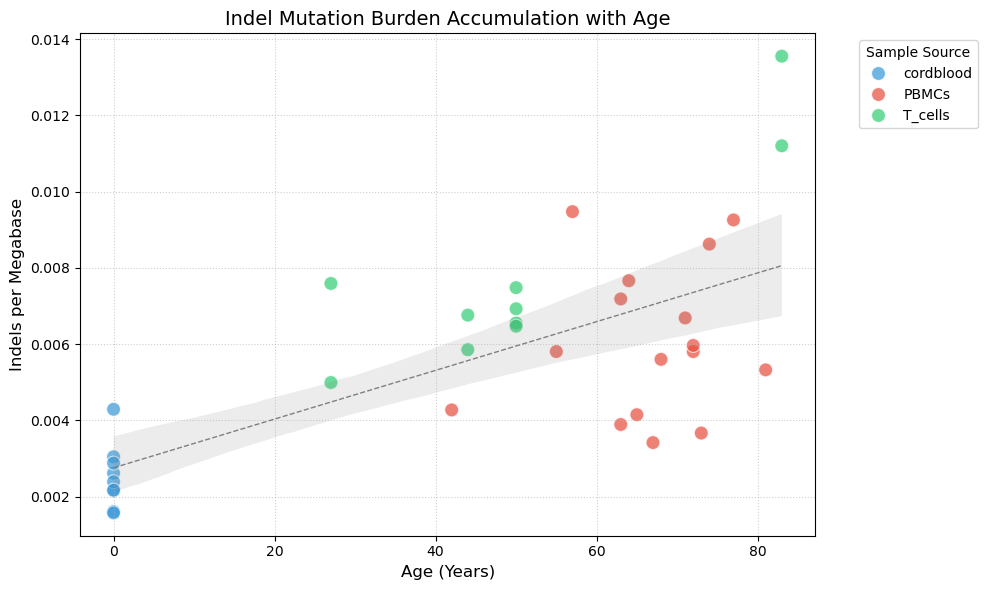

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean and Standardize the existing burden dataframe
# We don't need to re-parse the VCFs! Use the mutation_count from your first script.
df_plot = df_burden.copy()

# Filter out the problematic sample
df_plot = df_plot[df_plot['sample_id'] != 'Cordblood_H1']

# Standardize sample types for the plot legend
type_mapping = {
    'cord': 'cordblood',
    'LEGACY': 'PBMCs',
    'UKCTOCS': 'PBMCs'
}
df_plot['sample_type'] = df_plot['sample_type'].replace(type_mapping)

# 2. Visualization: Indel Burden vs Age
plt.figure(figsize=(10, 6))

# Define a color palette for your types
palette = {
    'cordblood': '#3498db', 
    'PBMCs': '#e74c3c', 
    'T_cells': '#2ecc71' # Add others as they appear in your data
}

sns.scatterplot(
    data=df_plot,
    x='age',
    y='mutations_per_mb_sequenced',
    hue='sample_type',
    palette=palette,
    s=100,
    alpha=0.7,
    edgecolor='w'
)

# Add a regression line to show the accumulation over time
sns.regplot(
    data=df_plot,
    x='age',
    y='mutations_per_mb_sequenced',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'linewidth': 1}
)

plt.title('Indel Mutation Burden Accumulation with Age', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Indels per Megabase', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Sample Source', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

[INFO] Observed Mean Indel Rate: 2.53e-09
[INFO] Expected Reference Rate: 2.00e-09


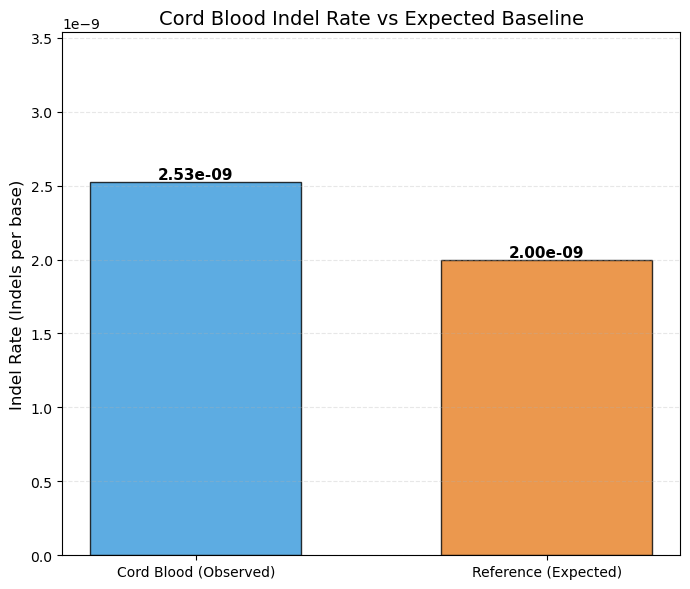

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# 1. Configuration
# -----------------------
# Using your specific Indel reference rate
REFERENCE_RATE_INDEL = 2e-9 

# -----------------------
# 2. Prepare Data for Plotting
# -----------------------
# Filter for Cord Blood samples
cord_data = df_plot[df_plot['sample_type'] == 'cordblood']

if cord_data.empty:
    print("[WARNING] No cordblood data found in df_plot.")
    # Fallback: check for 'cord' if standardizing hasn't happened yet
    cord_data = df_plot[df_plot['sample_type'] == 'cord']

if cord_data.empty:
    current_rate = 0
else:
    # Use the mutation_count / bases (burden) we calculated in the loading script
    # We use 'indel_burden' if you kept that column, 
    # or calculate it on the fly: (mutation_count / bases)
    if 'indel_burden' in cord_data.columns:
        current_rate = cord_data['indel_burden'].mean()
    else:
        # Based on the burden calculation in your previous loading script:
        # mutation_count / bases
        current_rate = (cord_data['mutation_count'] / cord_data['bases']).mean()

labels = ['Cord Blood (Observed)', 'Reference (Expected)']
rates = [current_rate, REFERENCE_RATE_INDEL]
colors = ['#3498db', '#e67e22']  # Blue for data, Orange for Reference

# -----------------------
# 3. Plotting
# -----------------------
fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(labels, rates, color=colors, edgecolor='k', alpha=0.8, width=0.6)

# Styling
ax.set_ylabel("Indel Rate (Indels per base)", fontsize=12)
ax.set_title("Cord Blood Indel Rate vs Expected Baseline", fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2e}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Scientific notation for Y axis is cleaner for these small numbers
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.set_ylim(0, max(rates) * 1.4)

plt.tight_layout()

# -----------------------
# 4. Display
# -----------------------
print(f"[INFO] Observed Mean Indel Rate: {current_rate:.2e}")
print(f"[INFO] Expected Reference Rate: {REFERENCE_RATE_INDEL:.2e}")

plt.show()

Rendering T-cells + Cordblood Indel Figure...


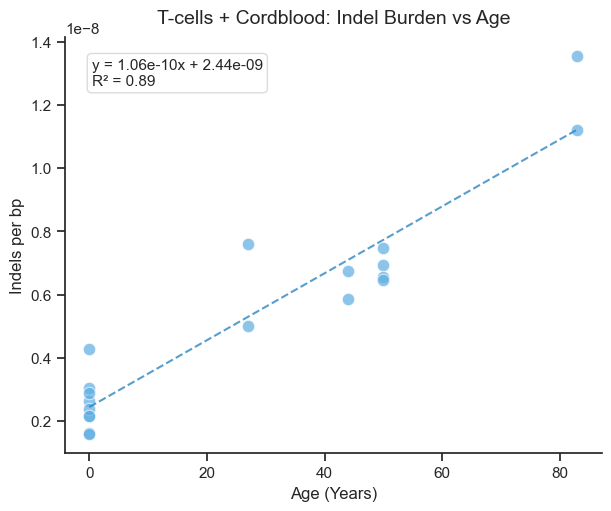

Rendering PBMCs + Cordblood Indel Figure...


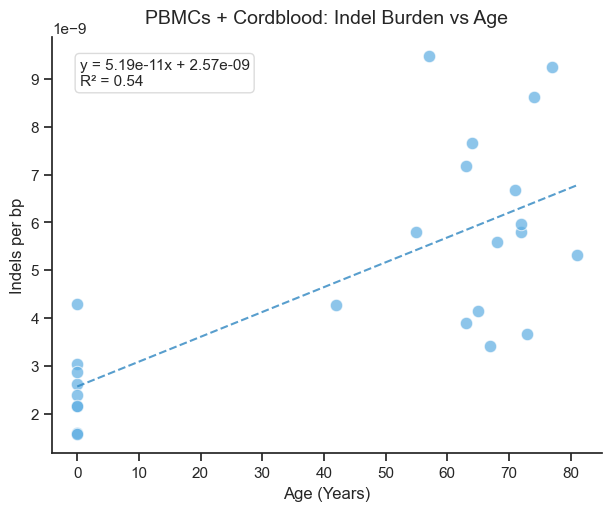

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Set a clean theme
sns.set_theme(style="ticks")

def plot_indel_burden(df_subset, title_prefix):
    # Ensure we are using the Indel-specific burden
    # If the column 'indel_burden' doesn't exist, calculate it on the fly
    if 'indel_burden' not in df_subset.columns:
        df_subset = df_subset.copy()
        df_subset['indel_burden'] = df_subset['mutation_count'] / df_subset['bases']

    # Create a single figure
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    
    # 1. Scatter Plot
    sns.scatterplot(
        data=df_subset, 
        x='age', 
        y='indel_burden', 
        color='#5DADE2', # A soft blue to distinguish from the SNV grey
        marker='o',
        s=80, 
        alpha=0.7,
        ax=ax
    )
    
    # 2. Linear Regression
    df_clean = df_subset.dropna(subset=['age', 'indel_burden'])
    x = df_clean['age'].values
    y = df_clean['indel_burden'].values
    
    if len(x) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        line_x = np.array([0, max(x)])
        line_y = slope * line_x + intercept
        
        # Plot the trend line
        ax.plot(line_x, line_y, color='#2E86C1', linestyle='--', alpha=0.8)
        
        # 3. Display the equation and R^2
        # Using .2e for scientific notation as Indel values are small
        eq_text = f"y = {slope:.2e}x + {intercept:.2e}\nR² = {r_value**2:.2f}"
        ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, 
                fontsize=11, verticalalignment='top', 
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='lightgray', facecolor='white', alpha=0.8))

    # 4. Clean up axes
    ax.set_title(f'{title_prefix}: Indel Burden vs Age', fontsize=14, pad=10)
    ax.set_xlabel('Age (Years)', fontsize=12)
    ax.set_ylabel('Indels per bp', fontsize=12)
    
    # Set Y-axis to scientific notation for clarity
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
    sns.despine(ax=ax)
    plt.show()

# --- Create the specific figures ---

# Figure 1: T-cells + Cordblood
# Note: I fixed the typo 'corblood' -> 'cordblood' from your snippet
df_tcells = df_plot[df_plot['sample_type'].isin(['T_cells', 'cordblood'])]
print("Rendering T-cells + Cordblood Indel Figure...")
plot_indel_burden(df_tcells, "T-cells + Cordblood")

# Figure 2: PBMCs + Cordblood
df_pbmcs = df_plot[df_plot['sample_type'].isin(['PBMCs', 'cordblood'])]
print("Rendering PBMCs + Cordblood Indel Figure...")
plot_indel_burden(df_pbmcs, "PBMCs + Cordblood")

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_86564/3674366763.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TYPE', ax=axes[0, 0], palette="Set2", order=['INS', 'DEL'])


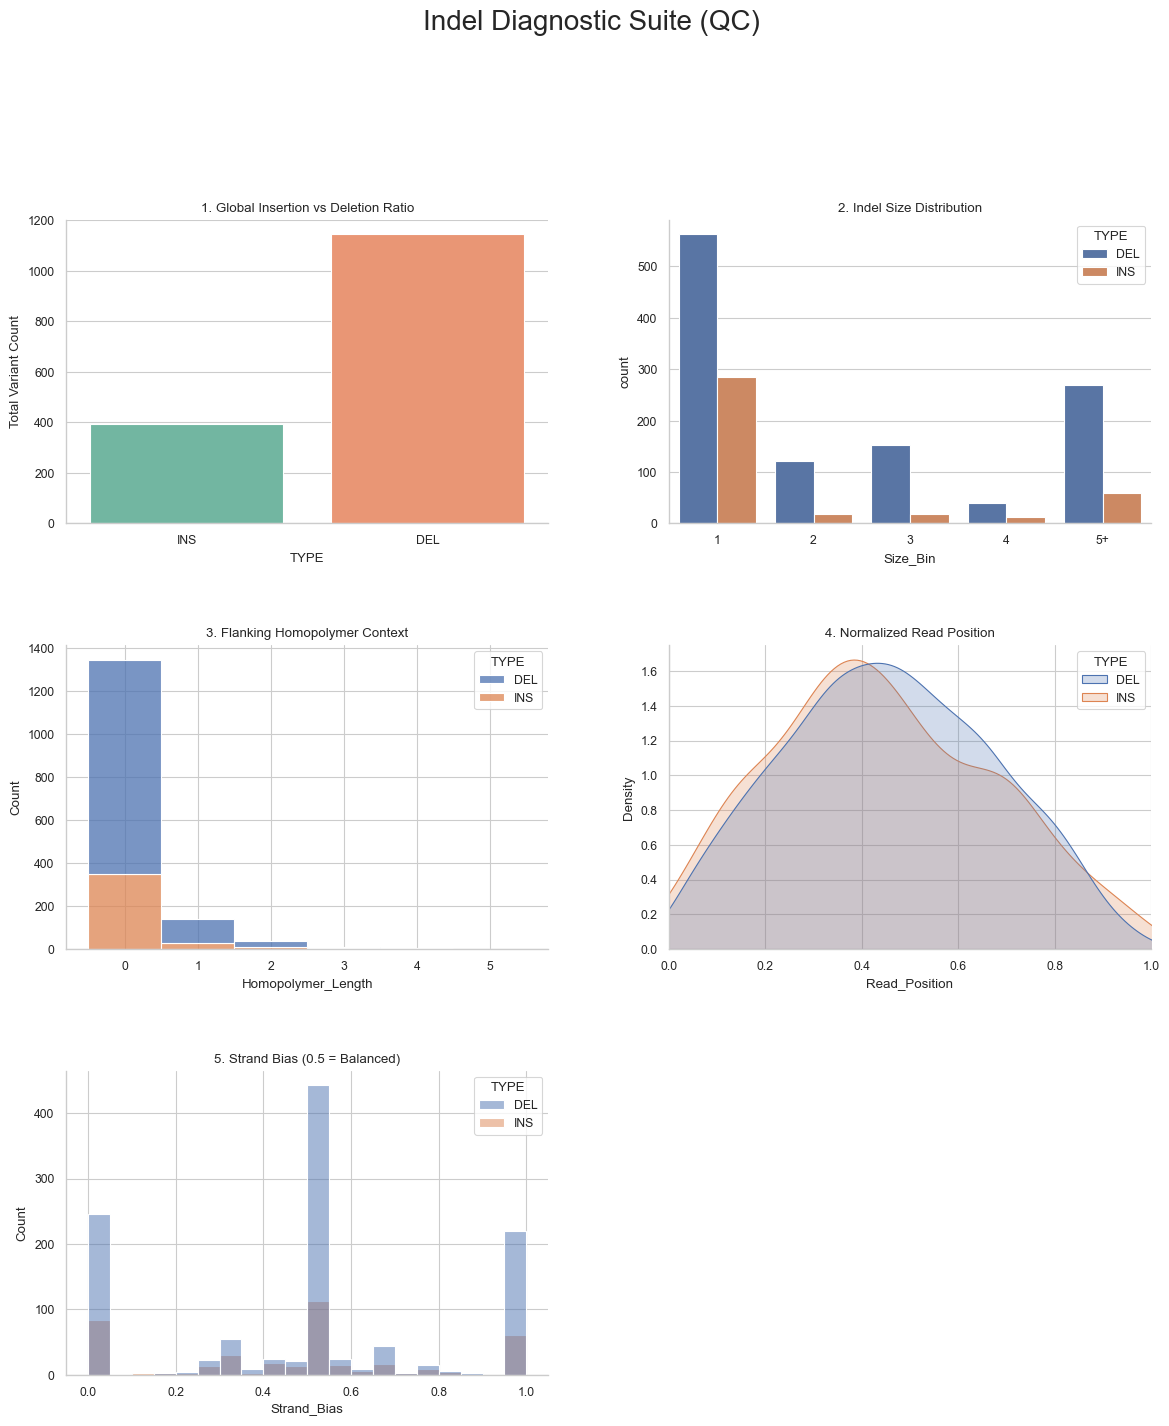

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_integrated_diagnostics(df):
    if df.empty:
        print("No variants found to plot.")
        return

    sns.set_theme(style="whitegrid", context="paper")
    
    # Expanded to 3 rows to include the Insertion vs Deletion comparison
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle("Indel Diagnostic Suite (QC)", fontsize=20, y=1.02)
    plt.subplots_adjust(hspace=0.4, wspace=0.25)

    # --- 1. INSERTION VS DELETION COUNT ---
    # This checks the global ratio of Indel types
    sns.countplot(data=df, x='TYPE', ax=axes[0, 0], palette="Set2", order=['INS', 'DEL'])
    axes[0, 0].set_title("1. Global Insertion vs Deletion Ratio")
    axes[0, 0].set_ylabel("Total Variant Count")

    # --- 2. SIZE DISTRIBUTION ---
    # Biological indels should show an exponential decay (shorter is more common)
    df['Size_Bin'] = df['LEN'].apply(lambda x: str(x) if x < 5 else '5+')
    sns.countplot(data=df, x='Size_Bin', hue='TYPE', order=['1','2','3','4','5+'], ax=axes[0, 1])
    axes[0, 1].set_title("2. Indel Size Distribution")

    # --- 3. HOMOPOLYMER CONTEXT ---
    # High HP lengths are prone to polymerase slippage errors
    sns.histplot(data=df, x='Homopolymer_Length', hue='TYPE', multiple='stack', discrete=True, ax=axes[1, 0])
    axes[1, 0].set_title("3. Flanking Homopolymer Context")
    

    # --- 4. READ POSITION ---
    # Spikes at 0 or 1 indicate alignment/soft-clipping artifacts
    sns.kdeplot(data=df, x='Read_Position', hue='TYPE', fill=True, ax=axes[1, 1], common_norm=False)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_title("4. Normalized Read Position")

    # --- 5. STRAND BIAS ---
    # Most real somatic mutations should be roughly balanced (~0.5)
    sns.histplot(data=df, x='Strand_Bias', hue='TYPE', bins=20, ax=axes[2, 0])
    axes[2, 0].set_title("5. Strand Bias (0.5 = Balanced)")

    # Clear the empty 6th plot
    fig.delaxes(axes[2, 1])

    sns.despine()
    plt.show()

# Run the suite
plot_integrated_diagnostics(df_variants)

In [7]:
import os
import shutil
import glob
import gzip
from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen
from SigProfilerExtractor import sigpro as sig

# --- 1. SETUP & AGGREGATE VCFS ---
INPUT_DIR = "sigprofiler_input_indels"
if os.path.exists(INPUT_DIR):
    shutil.rmtree(INPUT_DIR)
os.makedirs(INPUT_DIR, exist_ok=True)

# Use the data_dir we defined in your loading script
vcf_source_dir = "../../../data/indels/filtered_vcf"

print(f"Aggregating VCFs from {vcf_source_dir}...")
vcf_files = glob.glob(os.path.join(vcf_source_dir, "*.vcf.gz")) + \
            glob.glob(os.path.join(vcf_source_dir, "*.vcf"))

for vcf_path in vcf_files:
    base_name = os.path.basename(vcf_path)
    out_name = base_name[:-3] if base_name.endswith('.gz') else base_name
    out_path = os.path.join(INPUT_DIR, out_name)
    
    # Decompress to ensure SigProfiler doesn't have format issues
    if vcf_path.endswith('.gz'):
        with gzip.open(vcf_path, 'rb') as f_in, open(out_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    else:
        shutil.copy(vcf_path, out_path)

# --- 2. GENERATE MATRICES ---
# This step creates the ID83 matrix needed for extraction
matGen.SigProfilerMatrixGeneratorFunc(
    "Indel_Cohort", "GRCh38", INPUT_DIR, 
    plot=True, exome=False, cushion=100
)

# --- 3. RUN EXTRACTION ---
# Note: Indel signature extraction is computationally heavier than SNVs.
# 'nmf_replicates=10' is good for a quick look; use 100 for final results.
id83_matrix_path = os.path.join(INPUT_DIR, "output", "ID", "Indel_Cohort.ID83.all")

sig.sigProfilerExtractor(
    "matrix", "sigprofiler_output", id83_matrix_path, 
    reference_genome="GRCh38", 
    minimum_signatures=1, 
    maximum_signatures=5, # Typically 3-5 is the sweet spot for blood/aging cohorts
    nmf_replicates=10
)

Aggregating VCFs from ../../../data/indels/filtered_vcf...
Starting matrix generation for INDELs...Completed! Elapsed time: 9.7 seconds.
Matrices generated for 36 samples with 0 errors. Total of 0 SNVs, 0 DINUCs, and 1540 INDELs were successfully analyzed.

************** Reported Current Memory Use: 0.84 GB *****************

Extracting signature 1 for mutation type INDEL
The matrix normalizing cutoff is 8300


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    1.7s remaining:    1.9s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    1.7s remaining:    0.7s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    1.7s remaining:    0.2s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    1.8s finished



 Decomposing De Novo Signatures  .....
Decompositon Plot:ID83A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (32967.46/s) 
Decompositon Plot:ID83B |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (25131.32/s) 

 Assigning decomposed signature


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    0.0s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 


✅ Loading: sigprofiler_output/ID83/Suggested_Solution/COSMIC_ID83_Decomposed_Solution/Activities/COSMIC_ID83_Activities.txt
📊 Signatures found: ['ID25', 'ID8', 'ID23', 'ID2', 'ID7']


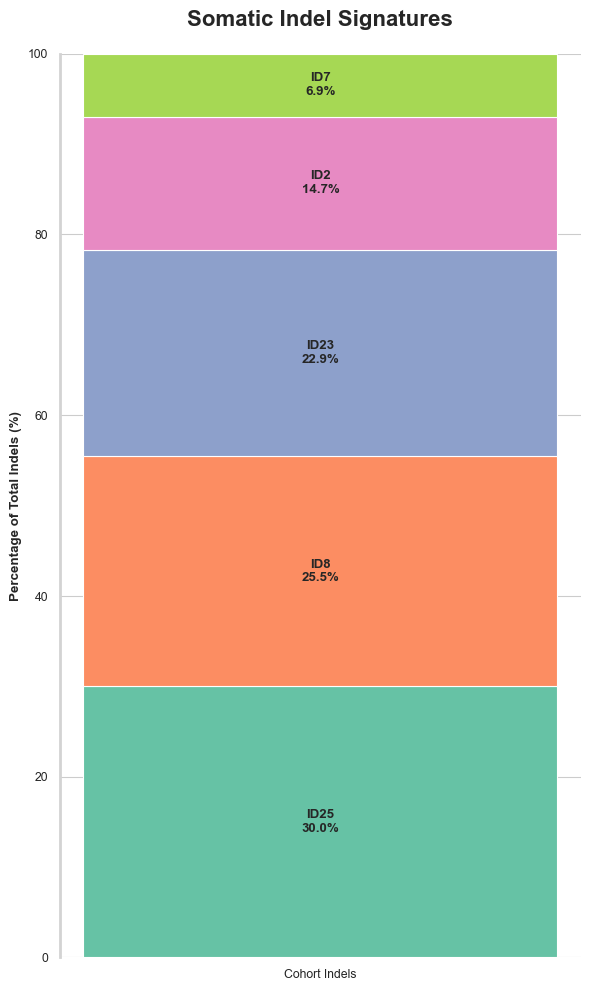

In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import numpy as np

# 1. Dynamic Path Discovery
# This looks for any file ending in Activities.txt or Activities_refit.txt 
# inside your output directory, regardless of the folder nesting.
search_pattern = "sigprofiler_output/**/COSMIC_ID83_Activities*.txt"
found_files = glob.glob(search_pattern, recursive=True)

if not found_files:
    print("❌ ERROR: No activities file found.")
    # Debug: Print everything in the directory to see where we are
    print("Files present in sigprofiler_output:")
    for root, dirs, files in os.walk("sigprofiler_output"):
        for f in files:
            print(os.path.join(root, f))
else:
    # Prioritize 'refit' if it exists, otherwise take the first match
    activities_path = next((f for f in found_files if "refit" in f), found_files[0])
    print(f"✅ Loading: {activities_path}")
    
    df_act = pd.read_csv(activities_path, sep="\t")
    
    # 2. Set Index
    if 'Samples' in df_act.columns:
        df_act = df_act.set_index('Samples')
    else:
        df_act = df_act.set_index(df_act.columns[0])

    # 3. Numeric Calculation
    df_numeric = df_act.select_dtypes(include=[np.number])
    
    # Remove metadata columns if they exist
    for col in ['total', 'Total', 'unassigned']:
        if col in df_numeric.columns:
            df_numeric = df_numeric.drop(columns=[col])
        
    total_counts = df_numeric.sum(axis=0).sort_values(ascending=False)
    
    if total_counts.sum() == 0:
        print("⚠️ WARNING: Total mutation count is 0.")
    else:
        proportions = (total_counts / total_counts.sum()) * 100
        print(f"📊 Signatures found: {list(total_counts.index)}")

        # 4. Plotting
        plt.figure(figsize=(6, 10))
        colors = sns.color_palette("Set2", len(proportions))
        
        bottom = 0
        for i, (sig_name, pct) in enumerate(proportions.items()):
            plt.bar("Cohort Indels", pct, bottom=bottom, color=colors[i], edgecolor='white', width=0.6)
            
            label_y = bottom + (pct / 2)
            if pct > 5:
                plt.text(0, label_y, f"{sig_name}\n{pct:.1f}%", ha='center', va='center', weight='bold')
            elif pct > 1.0:
                plt.text(0.35, label_y, f" {sig_name} ({pct:.1f}%)", ha='left', va='center', fontsize=10)
            bottom += pct

        plt.ylim(0, 100)
        plt.title("Somatic Indel Signatures", fontsize=16, weight='bold', pad=20)
        plt.ylabel("Percentage of Total Indels (%)", weight='bold')
        sns.despine(bottom=True)
        plt.tick_params(bottom=False)
        plt.tight_layout()
        plt.show()

Total indels available for recurrence analysis: 1540


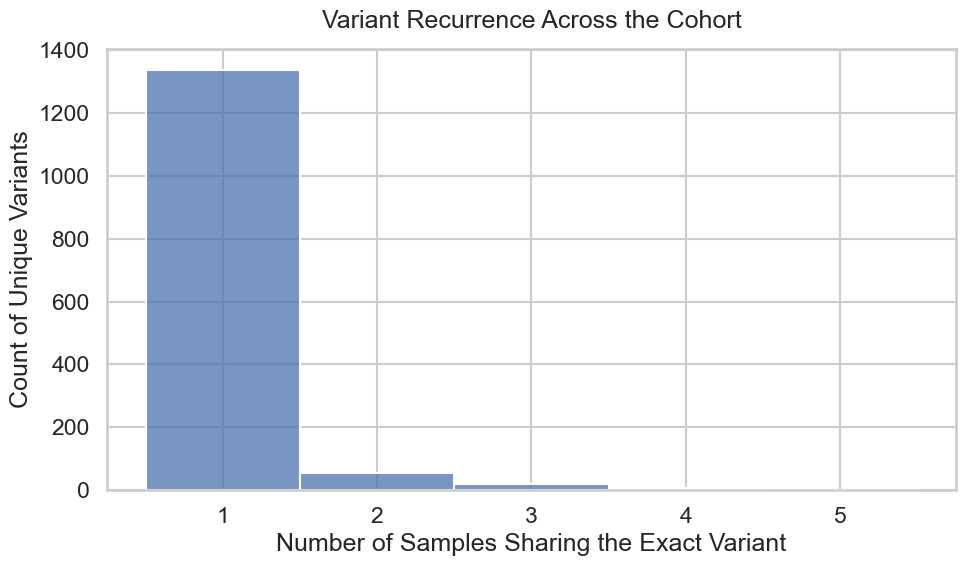


--- TOP 20 RECURRENT INDEL HOTSPOTS ---
Fetching gene annotations from Ensembl...
               Gene                                         Variant_ID  \
1            LILRB5                                chr19:54250979_GA>G   
2           SLC23A2                                 chr20:4869922_TG>T   
3             TRPM4  chr19:49182771_CCAAAGCCCCAGCCCTAAAAGGGGGAGCTGC...   
4             AP3S1                              chr5:115895100_CATT>C   
5          MIS18BP1                                chr14:45246815_A>AT   
6              TPTE                               chr21:10602053_CAT>C   
7             MAGI1                                chr3:65387174_TTC>T   
8            STXBP2                                chr19:7639950_ATG>A   
9           FAM111B                                chr11:59124903_CA>C   
10            TDRD6                                 chr6:46692677_G>GA   
11  ENSG00000295734                                 chr7:18654811_CA>C   
12       Intergenic          

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid", context="talk")

def get_gene_from_ensembl(chrom, pos, build="grch38"):
    chrom_clean = str(chrom).replace("chr", "")
    server = "https://rest.ensembl.org" if build.lower() == "grch38" else "https://grch37.rest.ensembl.org"
    ext = f"/overlap/region/human/{chrom_clean}:{pos}-{pos}?feature=gene"
    
    try:
        r = requests.get(server + ext, headers={"Content-Type": "application/json"})
        if not r.ok: return "API_Error"
        decoded = r.json()
        return decoded[0].get('external_name', decoded[0].get('id', 'Unknown')) if decoded else "Intergenic"
    except:
        return "Request_Failed"

# 1. Use the main variants dataframe
# Use df_variants (the concatenated df) rather than df_sample_vars (the single-sample df)
df_variants['Variant_ID'] = df_variants['CHROM'] + ":" + df_variants['POS'].astype(str) + "_" + df_variants['REF'] + ">" + df_variants['ALT']

print(f"Total indels available for recurrence analysis: {len(df_variants)}")

# 2. Calculate Recurrence
recurrence = df_variants.groupby("Variant_ID").agg(
    Num_Samples=('sample_id', 'nunique'),
    Chrom=('CHROM', 'first'),
    Pos=('POS', 'first')
).reset_index().sort_values(by="Num_Samples", ascending=False)

# 3. Plot Recurrence Distribution
# Using fig, ax syntax to avoid the AttributeError
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=recurrence, x="Num_Samples", discrete=True, color="#4c72b0", ax=ax)

ax.set_title("Variant Recurrence Across the Cohort", fontsize=18, pad=15)
ax.set_xlabel("Number of Samples Sharing the Exact Variant")
ax.set_ylabel("Count of Unique Variants")

# Correct way to set the locator on the axis object
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# 4. Top 20 Hotspot Annotation
print("\n--- TOP 20 RECURRENT INDEL HOTSPOTS ---")
top_20 = recurrence.head(20).copy()

print("Fetching gene annotations from Ensembl...")
genes = []
for idx, row in top_20.iterrows():
    genes.append(get_gene_from_ensembl(row['Chrom'], row['Pos']))
    time.sleep(0.1) 
        
top_20['Gene'] = genes
top_20.index = range(1, len(top_20) + 1)
print(top_20[['Gene', 'Variant_ID', 'Num_Samples']])

# 5. Technical Artifact Check
blacklist_genes = ['MUC16', 'TTN', 'HLA-A', 'HLA-B', 'HLA-C', 'MUC19', 'CDC27']
found_blacklist = top_20[top_20['Gene'].isin(blacklist_genes)]

if not found_blacklist.empty:
    print("\n⚠️ ALERT: Potential Artifact Genes Detected in Hotspots!")
    print(f"Found: {', '.join(found_blacklist['Gene'].unique())}")